# Analisis de Desempleo en Latinoamerica

Notebook limpio para analisis exploratorio de desempleo con datos del Banco Mundial.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



In [33]:
df_raw = pd.read_csv('data/API_SL.UEM.TOTL.ZS_DS2_es_csv_v2_1408.csv', skiprows=4)
df_meta = pd.read_csv('data/Metadata_Country_API_SL.UEM.TOTL.ZS_DS2_es_csv_v2_1408.csv')

In [34]:
df_meta

,Country Name,Country Code,Region,Income_Group,Unnamed: 4
0,Aruba,ABW,NaN,Ingreso alto,NaN
1,NaN,AFE,NaN,Agregados,NaN
2,Afganistán,AFG,Oriente Medio y Norte de África (excluido alto...,Países de ingreso bajo,NaN
3,NaN,AFW,NaN,Agregados,NaN
4,Angola,AGO,África al sur del Sahara (excluido altos ingre...,Países de ingreso mediano bajo,NaN
...,...,...,...,...,...
261,Kosovo,XKX,Europa y Asia central (excluido altos ingresos),Ingreso mediano alto,NaN
262,"Yemen, Rep. del",YEM,Oriente Medio y Norte de África (excluido alto...,Países de ingreso bajo,NaN
263,Sudáfrica,ZAF,África al sur del Sahara (excluido altos ingre...,Ingreso mediano alto,NaN
264,Zambia,ZMB,África al sur del Sahara (excluido altos ingre...,Países de ingreso mediano bajo,NaN


In [35]:
df_raw

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.214915,7.244843,7.459106,7.974302,8.407412,7.869470,7.676548,7.571697,7.539234,NaN
2,Afganistán,AFG,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,11.192000,11.187000,11.710000,12.006000,14.100000,14.008000,13.687000,13.351000,NaN
3,NaN,AFW,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.283996,4.334377,4.390764,4.795318,4.666634,3.593354,3.200801,3.172421,3.190552,NaN
4,Angola,AGO,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.617000,16.602000,16.497000,16.696000,15.799000,14.124000,14.051000,14.020000,14.108000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep. del",YEM,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.611000,17.593000,17.213000,17.963000,18.312000,17.224000,16.944000,16.970000,17.322000,NaN
263,Sudáfrica,ZAF,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,27.035000,26.906000,28.468000,29.217000,34.007000,33.268000,32.098000,32.279000,32.391000,NaN
264,Zambia,ZMB,"Desempleo, total (% de la fuerza laboral total...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.529000,5.032000,5.538000,6.032000,5.197000,5.993000,5.861000,5.898000,5.918000,NaN


In [36]:
df_meta.columns

Index(['Country Name', 'Country Code', 'Region', 'Income_Group', 'Unnamed: 4'], dtype='object')

In [37]:
df_raw.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [38]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [39]:
missing = df_raw.isnull().sum()

In [40]:
missing

Country Name        2
Country Code        0
Indicator Name      0
Indicator Code      0
1960              266
                 ... 
2022               32
2023               34
2024               36
2025               36
Unnamed: 70       266
Length: 71, dtype: int64

In [8]:
null_percent = (df_raw.isnull().sum() / len(df_raw)) * 100
audit_report = pd.DataFrame({'Nulos Absolutos': df_raw.isnull().sum(), 'Porcentaje (%)': null_percent})

In [9]:
print(audit_report.loc[['1960', '1991', '2023']]) # Muestra ejemplos de evolución de nulos

      Nulos Absolutos  Porcentaje (%)
1960              266      100.000000
1991               31       11.654135
2023               34       12.781955


In [10]:
cols_to_drop = ['Indicator Name', 'Indicator Code', 'Unnamed: 70']
df_main = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])

In [11]:
year_cols = [col for col in df_main.columns if col.isdigit()]
df_long = df_main.melt(id_vars=['Country Name', 'Country Code'], 
                       value_vars=year_cols, var_name='Year', value_name='Unemployment_Rate')
df_long['Year'] = pd.to_numeric(df_long['Year'])

In [12]:
df_final = pd.merge(df_long, df_meta[['Country Code', 'Region', 'Income_Group']], on='Country Code', how='left')

In [13]:
df_countries = df_final.dropna(subset=['Region'])
df_countries = df_countries[df_countries['Region'] != '']

In [14]:
df_recent = df_countries[df_countries['Year'] >= 1991]

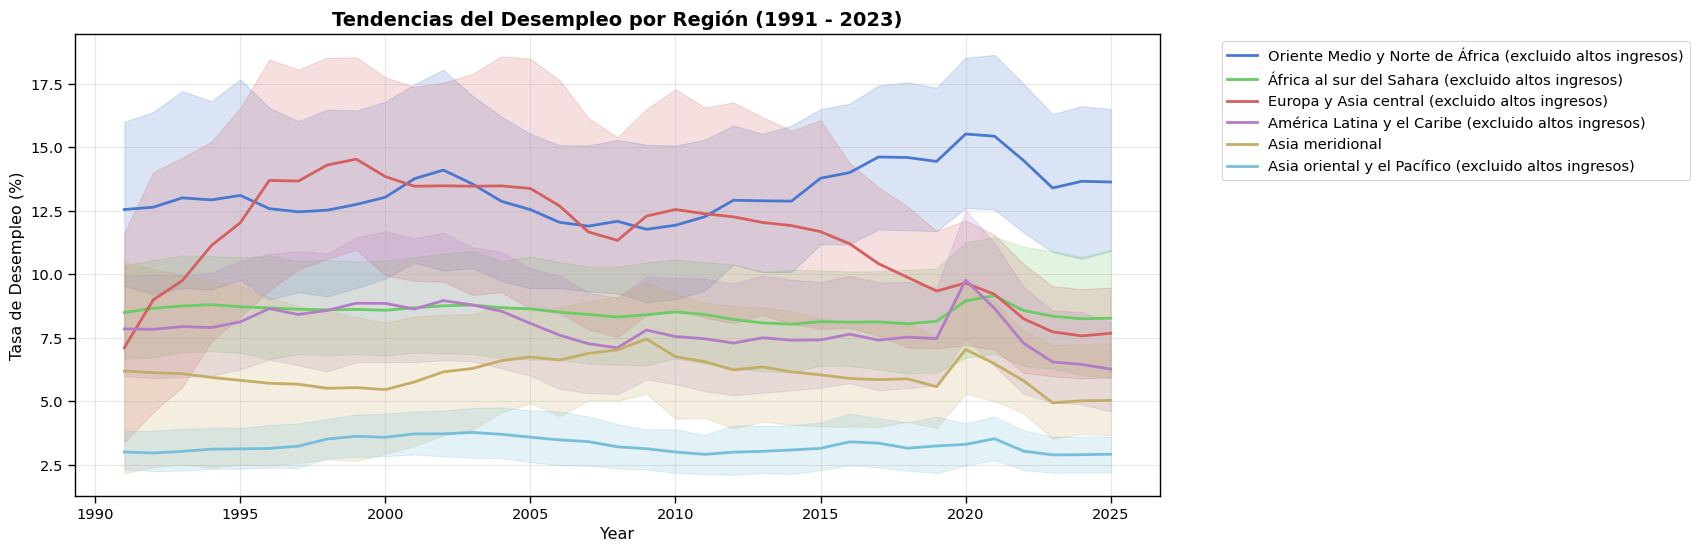

In [15]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_recent, x='Year', y='Unemployment_Rate', hue='Region', linewidth=2)
plt.title('Tendencias del Desempleo por Región (1991 - 2023)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Desempleo (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

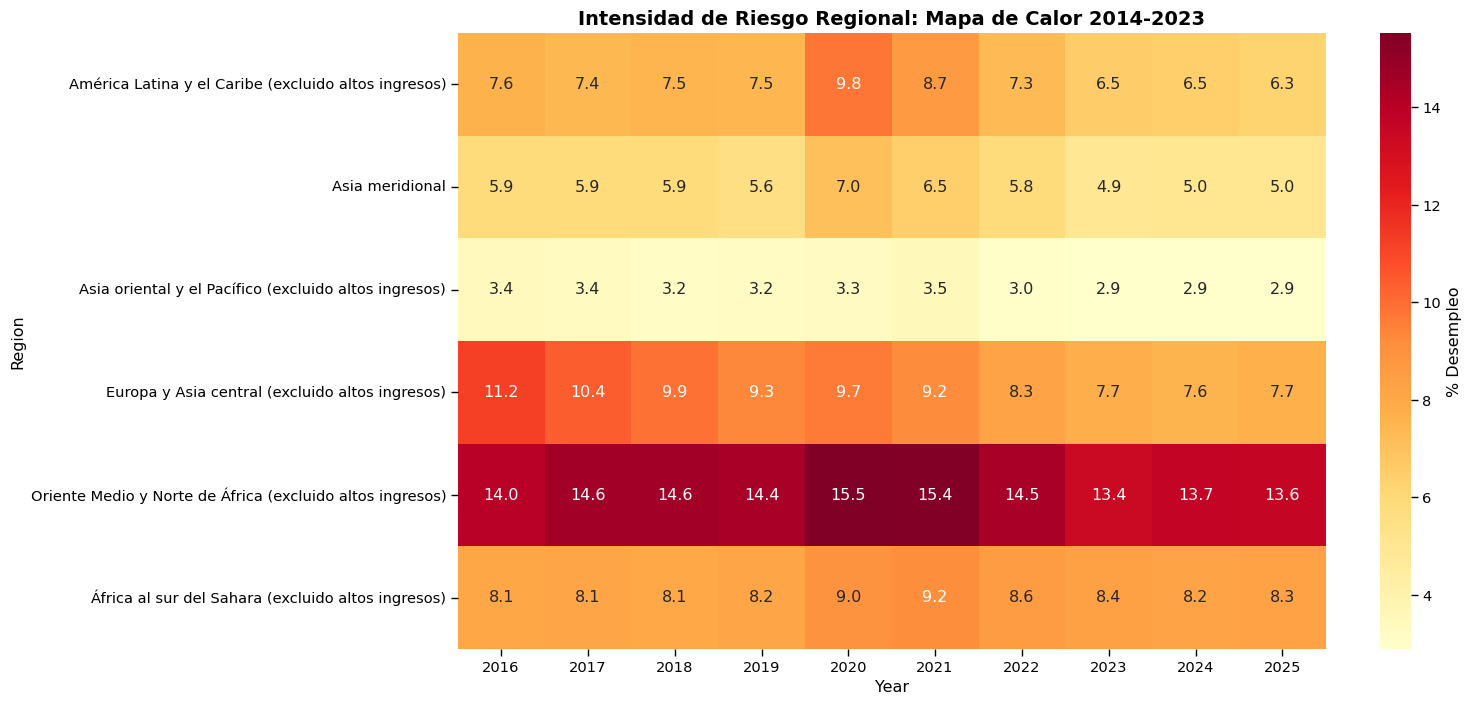

In [16]:
last_10_years = sorted(df_countries['Year'].unique())[-10:]
heatmap_data = df_countries[df_countries['Year'].isin(last_10_years)].groupby(['Region', 'Year'])['Unemployment_Rate'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd', cbar_kws={'label': '% Desempleo'})
plt.title('Intensidad de Riesgo Regional: Mapa de Calor 2014-2023', fontsize=14, fontweight='bold')
plt.show()

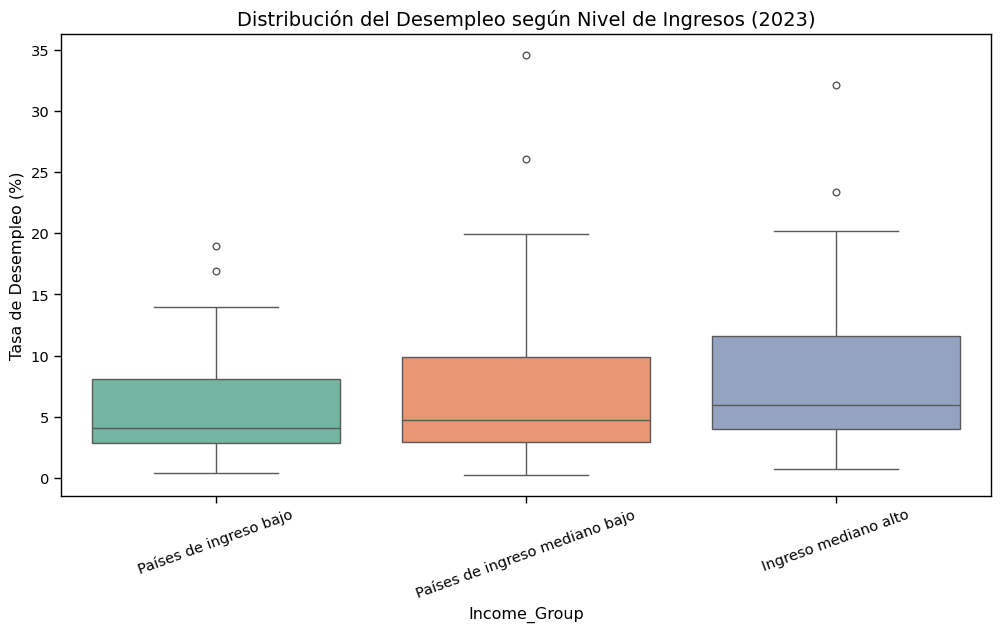

In [18]:
# Datos del último año registrado
data_2023 = df_countries[df_countries['Year'] == 2023].dropna(subset=['Unemployment_Rate'])

# Gráfico C: Boxplot por Grupo de Ingresos
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_2023, x='Income_Group', y='Unemployment_Rate', palette='Set2')
plt.xticks(rotation=20)
plt.title('Distribución del Desempleo según Nivel de Ingresos (2023)', fontsize=14)
plt.ylabel('Tasa de Desempleo (%)')
plt.show()

#

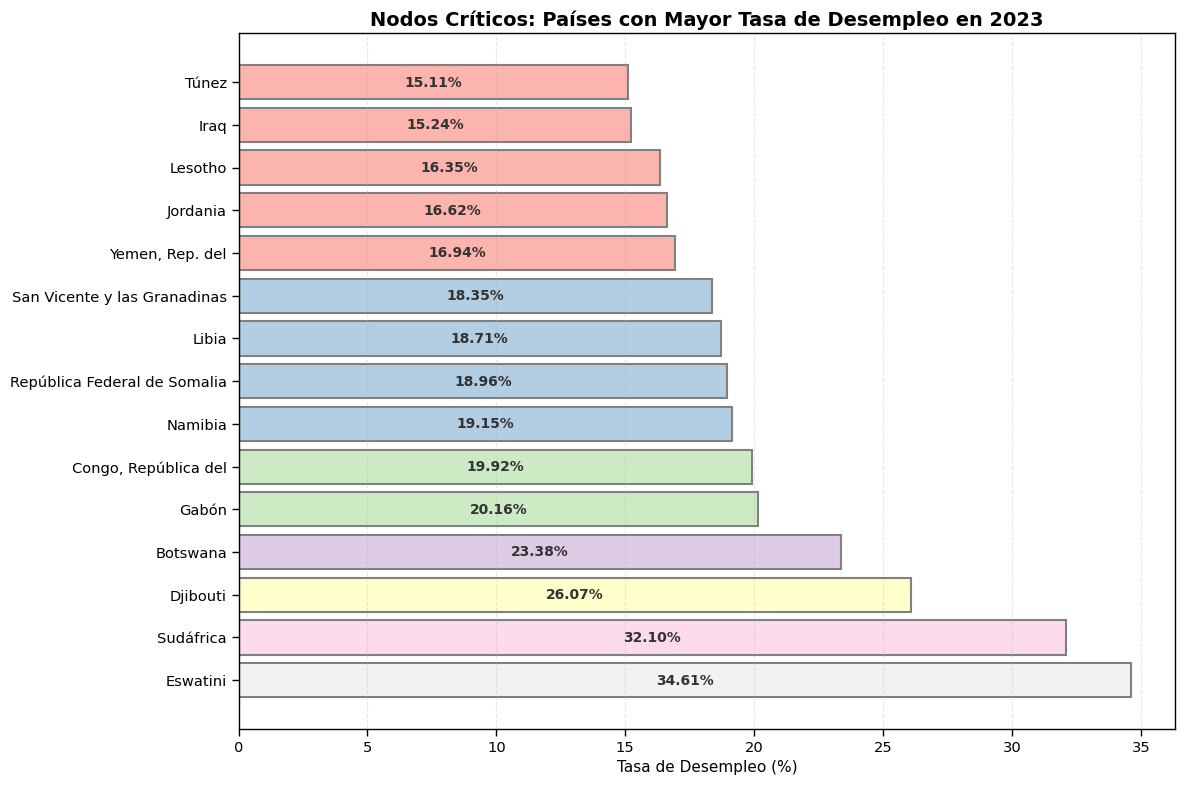

In [30]:
# Gráfico D: Top 15 de Países con mayor desempleo con gradiente pastel
import matplotlib.colors as mcolors

top_15 = data_2023.nlargest(15, 'Unemployment_Rate')

# Crear un gradiente de colores pastel
norm = mcolors.Normalize(vmin=top_15['Unemployment_Rate'].min(), vmax=top_15['Unemployment_Rate'].max())
colors_pastel = plt.cm.get_cmap('Pastel1')(norm(top_15['Unemployment_Rate'].values))

plt.figure(figsize=(12, 8))
bars = plt.barh(top_15['Country Name'], top_15['Unemployment_Rate'], color=colors_pastel, edgecolor='gray', linewidth=1.5)

# Añadir etiquetas dentro de las barras
for i, (idx, row) in enumerate(top_15.iterrows()):
    v = row['Unemployment_Rate']
    plt.text(v * 0.5, i, f"{v:.2f}%", va='center', ha='center', fontweight='bold', fontsize=10, color='#333333')

plt.title('Nodos Críticos: Países con Mayor Tasa de Desempleo en 2023', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Desempleo (%)', fontsize=11)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()